# Cytokines ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.ensemble import RandomSurvivalForest, ComponentwiseGradientBoostingSurvivalAnalysis, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc, concordance_index_ipcw
from sksurv.compare import compare_survival
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

In [2]:
print(plt.rcParams["font.family"])
plt.rcParams["font.sans-serif"] = ["Arial"] + plt.rcParams["font.sans-serif"]

['sans-serif']


In [3]:
# Load formatted cytokines data
df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260731.csv")

In [4]:
# Encode survival status as binary variable
df["survival_status_encoded"] = df["survival_status"].map({"alive": 0, "death": 1})
df = df.loc[df["cohort"] == "LLU"]
df

,sample_names,sample_id,cohort,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,...,qlq30score,hn35,pathologicstage,lvi,pni,survival_status,sx_to_lastfu,survival_2yrs,ss,survival_status_encoded
0,FF301C,FF301C,LLU,29.45,25.24,90.00,6.40,3.95,4.21,3.54,...,81.62,30.56,stage_I,no,no,alive,1839,alive,1,0
1,FF302C,FF302C,LLU,71.50,9.93,46.35,0.00,0.00,2.33,3.42,...,46.11,47.78,stage_IVA,no,yes,alive,1721,alive,4,0
2,FF303C,FF303C,LLU,54.54,18.38,54.01,46.49,18.90,1.37,4.15,...,57.56,45.68,stage_IVA,yes,no,death,48,death,4,1
3,FF304C,FF304C,LLU,132.67,27.47,81.82,6.89,3.95,4.56,9.69,...,19.23,94.44,stage_IVA,no,yes,death,131,death,3,1
4,FF305C,FF305C,LLU,28.01,13.63,66.20,5.44,0.92,3.04,2.42,...,76.67,17.44,stage_II,no,no,alive,1679,alive,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,FF522C,FF522C,LLU,27.76,1.46,50.11,0.00,0.00,1.54,15.13,...,64.53,52.75,stage_IVB,yes,yes,death,125,death,5,1
108,FF523C,FF523C,LLU,7.59,18.85,107.23,0.00,1.72,2.22,13.17,...,65.51,49.81,stage_IVB,yes,yes,alive,312,alive,6,0
109,FF525C,FF525C,LLU,15.46,0.00,60.94,0.00,0.00,2.35,1.88,...,89.10,6.37,stage_II,no,no,alive,391,alive,1,0
110,FF526C,FF526C,LLU,35.09,76.39,68.89,28.03,32.72,3.89,2.10,...,100.00,0.00,stage_I,no,no,alive,407,alive,1,0


In [5]:
# Map string labels to boolean: True = death observed, False = alive
event_observed = df["survival_status"].map(
    {"death": True, "alive": False}
)

# Check for NA values in survival_status mapping
assert event_observed.isna().sum() == 0, (
    f"Unmapped survival_status values found: "
    f"{df['survival_status'][event_observed.isna()].unique()}"
)

# Create structured array for survival analysis
y = Surv.from_arrays(
        event=event_observed,
        time=df["sx_to_lastfu"]
    )

y

array([(False, 1839.), (False, 1721.), ( True,   48.), ( True,  131.),
       (False, 1679.), ( True,  318.), ( True,  278.), (False, 1765.),
       (False, 1758.), ( True,  997.), ( True,  482.), ( True,  592.),
       (False, 1625.), (False, 1592.), (False, 1406.), ( True,   84.),
       ( True,  253.), ( True,   51.), (False, 1582.), (False, 1510.),
       (False, 1500.), (False, 1485.), (False, 1410.), (False, 1475.),
       ( True,  689.), ( True, 1055.), ( True,  433.), (False,  634.),
       ( True,  665.), (False, 1268.), ( True,  330.), (False, 1274.),
       (False, 1282.), (False,  765.), (False, 1123.), (False, 1094.),
       ( True,  618.), ( True,  490.), (False, 1137.), (False, 1095.),
       (False, 1050.), ( True,  494.), ( True,  597.), (False, 1085.),
       ( True,  379.), ( True,  355.), (False, 1078.), ( True,  385.),
       ( True,   87.), ( True,  763.), (False,  907.), (False,  814.),
       (False, 1018.), (False, 1014.), (False,  945.), (False,  631.),
      

In [6]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "ages", "sex", "race", "tobaccouse", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [7]:
# Subset cytokines and cohort columns for analysis
cytokines_llu_df = df.loc[:, cytokines + ["cohort", "ss", "survival_status_encoded"]]
cytokines_llu_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,cohort,ss,survival_status_encoded
0,29.45,25.24,90.00,6.40,3.95,4.21,3.54,4.14,3.92,25.93,3.32,18.74,10.46,83.27,381.47,263.05,LLU,1,0
1,71.50,9.93,46.35,0.00,0.00,2.33,3.42,4.53,75.20,2.90,1.52,25.54,3.74,75.20,923.75,237.53,LLU,4,0
2,54.54,18.38,54.01,46.49,18.90,1.37,4.15,3.57,98.33,25.05,2.99,22.39,4.83,51.96,490.19,130.47,LLU,4,1
3,132.67,27.47,81.82,6.89,3.95,4.56,9.69,7.29,20.63,20.32,4.31,28.18,9.32,85.47,1148.22,34.22,LLU,3,1
4,28.01,13.63,66.20,5.44,0.92,3.04,2.42,5.44,10.63,17.14,3.98,39.61,5.94,71.54,1113.45,142.55,LLU,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,27.76,1.46,50.11,0.00,0.00,1.54,15.13,6.19,19.13,5.43,1.30,50.30,6.13,46.79,276.99,524.89,LLU,5,1
108,7.59,18.85,107.23,0.00,1.72,2.22,13.17,6.48,6.66,21.50,3.29,34.28,8.02,69.11,930.46,693.31,LLU,6,0
109,15.46,0.00,60.94,0.00,0.00,2.35,1.88,2.77,7.21,0.00,0.00,10.26,3.58,58.24,873.34,189.80,LLU,1,0
110,35.09,76.39,68.89,28.03,32.72,3.89,2.10,3.78,14.34,32.39,8.76,8.80,3.25,63.37,991.28,325.51,LLU,1,0


In [8]:
# Z-normalization of the cytokine values based on cohort (due to two different platforms on the two cohorts)
numeric_features = cytokines_llu_df.columns.drop(["cohort", "survival_status_encoded"])

sc = StandardScaler()

cytokines_llu_standardization_df = cytokines_llu_df.copy()
cytokines_llu_standardization_df[numeric_features] = (
    cytokines_llu_standardization_df[numeric_features]
    .transform(lambda x: sc.fit_transform(x.to_numpy().reshape(-1, 1)).ravel())
)

cytokines_llu_standardization_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,cohort,ss,survival_status_encoded
0,-0.148154,0.121418,1.409269,-0.236668,-0.106581,1.045099,-0.432814,-0.182359,-0.485307,0.100156,-0.195155,0.004131,0.184295,1.169596,-0.556037,0.084989,LLU,-1.501561,0
1,0.869503,-0.238375,-0.121928,-0.423888,-0.426731,0.134685,-0.441613,-0.089010,0.215519,-0.262735,-0.240695,0.635905,-0.203060,0.871403,1.079924,-0.022325,LLU,0.711266,0
2,0.459052,-0.039796,0.146777,0.936090,1.105124,-0.330206,-0.388083,-0.318792,0.442933,0.086290,-0.203504,0.343245,-0.140230,0.012666,-0.228049,-0.472525,LLU,0.711266,1
3,2.349885,0.173824,1.122323,-0.222334,-0.106581,1.214591,0.018162,0.571611,-0.321014,0.011758,-0.170107,0.881182,0.118583,1.250888,1.757109,-0.877267,LLU,-0.026343,1
4,-0.183004,-0.151423,0.574390,-0.264751,-0.352165,0.478512,-0.514943,0.128803,-0.419334,-0.038351,-0.178456,1.943120,-0.076247,0.736163,1.652214,-0.421727,LLU,-1.501561,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,-0.189054,-0.437425,0.009969,-0.423888,-0.426731,-0.247882,0.417074,0.308320,-0.335762,-0.222869,-0.246261,2.936306,-0.065295,-0.178370,-0.871235,1.186056,LLU,1.448874,1
108,-0.677190,-0.028750,2.013679,-0.423888,-0.287324,0.081417,0.273348,0.377733,-0.458367,0.030351,-0.195914,1.447921,0.043648,0.646372,1.100167,1.894280,LLU,2.186483,0
109,-0.486728,-0.471735,0.389874,-0.423888,-0.426731,0.144371,-0.554541,-0.510276,-0.452960,-0.308432,-0.279152,-0.783728,-0.212282,0.244717,0.927846,-0.223035,LLU,-1.501561,0
110,-0.011660,1.323470,0.668752,0.396077,2.225242,0.890135,-0.538408,-0.268527,-0.382858,0.201949,-0.057520,-0.919374,-0.231304,0.434275,1.283650,0.347640,LLU,-1.501561,0


In [9]:
def univariate_roc_grouping(df, cols, outcome_col):
    """
    For each column in `cols`, compute AUC vs `outcome_col`, determine
    association direction, find the Youden's J optimal threshold, and
    assign high/low group labels accordingly.

    Returns:
        results_df: summary table with AUC, direction, threshold per variable
        df: original dataframe with new f"{col}_group" columns added
    """
    results = []

    for col in cols:
        # drop rows with missing values for this column/outcome pair
        valid = df[[col, outcome_col]].dropna()
        y_true = valid[outcome_col].values
        score = valid[col].values

        if len(np.unique(y_true)) < 2:
            print(f"Skipping {col}: outcome has only one class after dropping NaNs")
            continue

        # AUC and direction
        auc = roc_auc_score(y_true, score)
        direction = "positive" if auc >= 0.5 else "negative"

        # Flip the score for ROC computation if direction is negative,
        # so Youden's J finds a meaningful maximum instead of the
        # degenerate inf/-inf threshold.
        roc_score = score if direction == "positive" else -score

        # ROC curve + Youden's J optimal threshold
        fpr, tpr, thresholds = roc_curve(y_true, roc_score)
        youden_j = tpr - fpr
        best_idx = np.argmax(youden_j)
        best_threshold = thresholds[best_idx]
        sensitivity = tpr[best_idx]
        specificity = 1 - fpr[best_idx]

        # assign high/low based on direction:
        # positive association -> higher values = "high" risk/group
        # negative association -> lower values = "high" risk/group
        if direction == "positive":
            group = np.where(df[col] > best_threshold, "high", "low")
        else:
            group = np.where(df[col] > best_threshold, "low", "high")

        df[f"{col}_group"] = group

        results.append({
            "variable": col,
            "auc": auc,
            "auc_abs": max(auc, 1 - auc),
            "direction": direction,
            "best_threshold": best_threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "n": len(valid),
        })

    results_df = pd.DataFrame(results).sort_values("auc_abs", ascending=False).reset_index(drop=True)
    return results_df, df

# Function call
outcome_col = "survival_status_encoded"

roc_summary, cytokines_llu_standardization_df = univariate_roc_grouping(cytokines_llu_standardization_df, numeric_features, outcome_col)

print(roc_summary)
print(cytokines_llu_standardization_df[[f"{c}_group" for c in numeric_features]].apply(pd.Series.value_counts))

     variable       auc   auc_abs direction  best_threshold  sensitivity  \
0          ss  0.764822  0.764822  positive       -0.026343     0.934783   
1         il6  0.714262  0.714262  positive       -0.326486     0.695652   
2         il8  0.669960  0.669960  positive        0.217365     0.478261   
3       vegfd  0.356555  0.643445  negative        0.234305     0.739130   
4       hbegf  0.637516  0.637516  positive       -0.389729     0.782609   
5        il10  0.635046  0.635046  positive       -0.356409     0.760870   
6    tnfalpha  0.628294  0.628294  positive       -0.066479     0.565217   
7    tgfalpha  0.587945  0.587945  positive       -0.246261     0.739130   
8    il1alpha  0.583169  0.583169  positive       -0.361872     0.630435   
9    ifngamma  0.555830  0.555830  positive       -0.111755     0.586957   
10    il1beta  0.555171  0.555171  positive       -0.365943     0.608696   
11  mip1alpha  0.546113  0.546113  positive       -0.126907     0.565217   
12        eg

## Univariate Kaplan-Meier Survival Curves

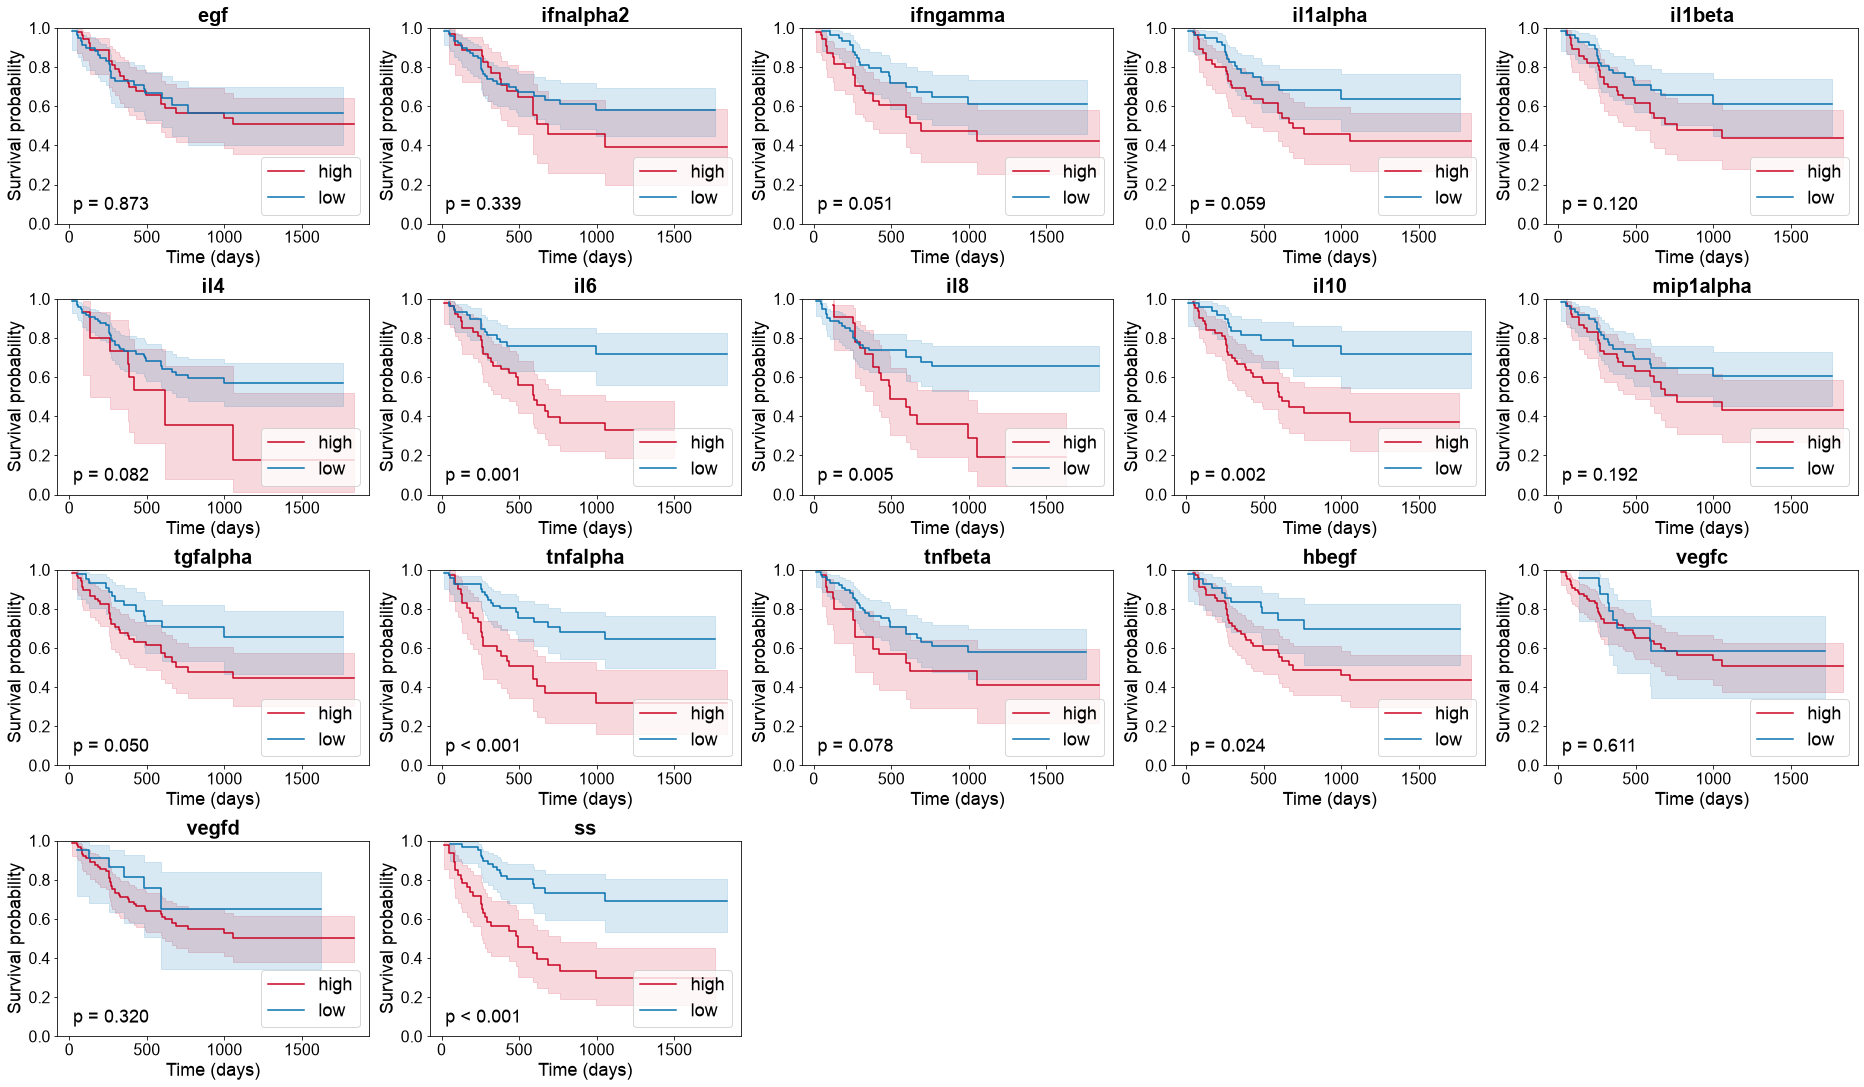

In [10]:
# Function to plot Kaplan-Meier survival curves in a grid, one panel per grouping variable
def plot_km_grid(df, y, group_cols, ncols=3, figsize_per_panel=(5.2, 3.8),
                          colors=("#CA0020", "#0571B0", "#4DAC26", "#FDB863", "#5E3C99"),
                          ci_alpha=0.15):
    """
    Plot Kaplan-Meier survival curves in a grid, one panel per grouping variable,
    using scikit-survival's kaplan_meier_estimator and compare_survival for the
    log-rank test.

    Parameters
    ----------
    df : DataFrame containing the group columns
    y : structured array with fields "event" (bool) and "time" (float),
        as used by scikit-survival (e.g. Surv.from_arrays(event, time))
    group_cols : list of column names in df to loop over
    """
    n = len(group_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0]*ncols, figsize_per_panel[1]*nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    # Force everything to plain numpy arrays, positionally aligned to df
    df = df.reset_index(drop=True)
    event_arr = np.asarray(y["event"]).reshape(-1)
    time_arr = np.asarray(y["time"]).reshape(-1)

    assert len(event_arr) == len(df), f"event length {len(event_arr)} != df length {len(df)}"
    assert len(time_arr) == len(df), f"time length {len(time_arr)} != df length {len(df)}"

    for i, col in enumerate(group_cols):
        ax = axes[i]
        col_vals = df[col].to_numpy()
        valid = pd.notna(col_vals)
        groups = sorted(pd.unique(col_vals[valid]))

        for g, color in zip(groups, colors):
            mask = valid & (col_vals == g)
            time_g, surv_prob_g, conf_int_g = kaplan_meier_estimator(
                event_arr[mask], time_arr[mask], conf_type="log-log"
            )
            ax.step(time_g, surv_prob_g, where="post", color=color, label=str(g))
            ax.fill_between(
                time_g, conf_int_g[0], conf_int_g[1],
                alpha=ci_alpha, step="post", color=color
            )

        # log-rank / chi-square test across groups (works for 2+ groups)
        _, p = compare_survival(y[valid], col_vals[valid])

        p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.text(
            0.05, 0.05, p_text, transform=ax.transAxes,
            fontsize=18, verticalalignment="bottom"
        )

        ax.set_ylim(0, 1)
        ax.set_title(col.replace("_group", ""), fontweight="bold", fontsize=20)
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=16)
        ax.set_xlabel("Time (days)", fontsize=18)
        ax.set_ylabel("Survival probability", fontsize=18)
        ax.legend(fontsize=18, loc="lower right")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    return fig


# Plot the Kaplan-Meier curves for each cytokine grouping variable
group_cols = [f"{c}_group" for c in numeric_features]
fig = plot_km_grid(cytokines_llu_standardization_df, y, group_cols, ncols=5)

# fig.savefig("../figures/llu_km_grid_sksurv.png", dpi=300, bbox_inches="tight")

## Multivariate Survival Models

In [11]:
# Specify the standardizednumeric features for the Cox model
X_full_standardized = cytokines_llu_standardization_df[numeric_features]

In [12]:
cytokines_llu_standardization_df[numeric_features]

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,ss
0,-0.148154,0.121418,1.409269,-0.236668,-0.106581,1.045099,-0.432814,-0.182359,-0.485307,0.100156,-0.195155,0.004131,0.184295,1.169596,-0.556037,0.084989,-1.501561
1,0.869503,-0.238375,-0.121928,-0.423888,-0.426731,0.134685,-0.441613,-0.089010,0.215519,-0.262735,-0.240695,0.635905,-0.203060,0.871403,1.079924,-0.022325,0.711266
2,0.459052,-0.039796,0.146777,0.936090,1.105124,-0.330206,-0.388083,-0.318792,0.442933,0.086290,-0.203504,0.343245,-0.140230,0.012666,-0.228049,-0.472525,0.711266
3,2.349885,0.173824,1.122323,-0.222334,-0.106581,1.214591,0.018162,0.571611,-0.321014,0.011758,-0.170107,0.881182,0.118583,1.250888,1.757109,-0.877267,-0.026343
4,-0.183004,-0.151423,0.574390,-0.264751,-0.352165,0.478512,-0.514943,0.128803,-0.419334,-0.038351,-0.178456,1.943120,-0.076247,0.736163,1.652214,-0.421727,-1.501561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,-0.189054,-0.437425,0.009969,-0.423888,-0.426731,-0.247882,0.417074,0.308320,-0.335762,-0.222869,-0.246261,2.936306,-0.065295,-0.178370,-0.871235,1.186056,1.448874
108,-0.677190,-0.028750,2.013679,-0.423888,-0.287324,0.081417,0.273348,0.377733,-0.458367,0.030351,-0.195914,1.447921,0.043648,0.646372,1.100167,1.894280,2.186483
109,-0.486728,-0.471735,0.389874,-0.423888,-0.426731,0.144371,-0.554541,-0.510276,-0.452960,-0.308432,-0.279152,-0.783728,-0.212282,0.244717,0.927846,-0.223035,-1.501561
110,-0.011660,1.323470,0.668752,0.396077,2.225242,0.890135,-0.538408,-0.268527,-0.382858,0.201949,-0.057520,-0.919374,-0.231304,0.434275,1.283650,0.347640,-1.501561


In [13]:
# Fit Cox Proportional Hazards model to the transformed data
estimator = CoxPHSurvivalAnalysis()
estimator.fit(cytokines_llu_standardization_df[numeric_features], y)

,alpha,0
,ties,'breslow'
,n_iter,100
,tol,1e-09
,verbose,0
Name,Type,Value
baseline_survival_,StepFunction,"StepFunction(... a=1.0, b=0.0)"
coef_,"ndarray[float64](17,)","[-0.24,-0.9 , 0.37,...,-0.56,-0.76, 0.88]"
cum_baseline_hazard_,StepFunction,"StepFunction(... a=1.0, b=0.0)"
feature_names_in_,"ndarray[object](17,)","['egf','ifnalpha2','ifngamma',...,'vegfc','vegfd','ss']"
n_features_in_,int,17


In [14]:
pd.Series(np.exp(estimator.coef_), index=X_full_standardized.columns).sort_values(ascending=False)

ss           2.403606
hbegf        1.930220
tnfalpha     1.592733
ifngamma     1.446922
il6          1.443599
il1beta      1.370272
il8          1.302824
il1alpha     1.143238
tgfalpha     1.085127
il4          0.965578
egf          0.783917
tnfbeta      0.676610
il10         0.650752
vegfc        0.570954
vegfd        0.469369
ifnalpha2    0.406404
mip1alpha    0.340669
dtype: float64

In [15]:
# Evaluate the model using concordance index
prediction = estimator.predict(X_full_standardized)
result = concordance_index_censored(y["event"], y["time"], prediction)
f"{result[0]:.5f}"

'0.79329'

In [16]:
# Concordance index for each feature using univariate Cox regression
def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = np.empty(n_features)
    m = CoxPHSurvivalAnalysis()
    for j in range(n_features):
        Xj = X[:, j : j + 1]
        m.fit(Xj, y)
        scores[j] = m.score(Xj, y)
    return scores


scores = fit_and_score_features(X_full_standardized.values, y)

c_index_scores_df = (
    pd.Series(scores, index=X_full_standardized.columns)
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index(name="c_index_score")
)

c_index_scores_df

,feature,c_index_score
0,ss,0.713639
1,il6,0.653303
2,tnfalpha,0.617874
3,vegfd,0.612413
4,il10,0.590836
5,hbegf,0.586042
6,il8,0.584576
7,ifngamma,0.554342
8,tnfbeta,0.547283
9,il1alpha,0.542754


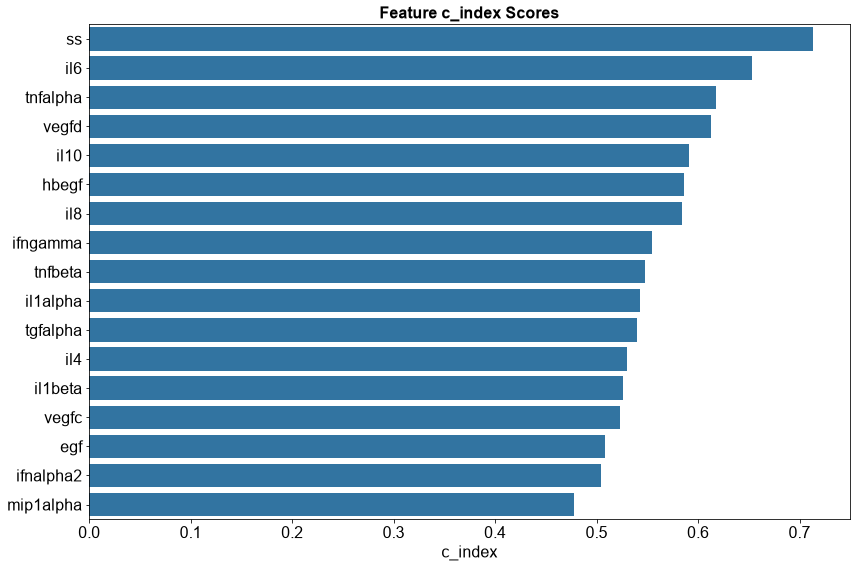

In [17]:
# Plot the c_index scores for each feature
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=c_index_scores_df,
    x="c_index_score",
    y="feature",
    order=c_index_scores_df["feature"],
    ax=ax
)

ax.set_xlabel("c_index", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylabel("", fontsize=16)
ax.set_title("Feature c_index Scores", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

# fig.savefig("../figures/feature_c_index_scores.png", dpi=300, bbox_inches="tight")

In [18]:
pipe = Pipeline(
    [
        ("select", SelectKBest(fit_and_score_features, k=3)),
        ("model", CoxPHSurvivalAnalysis()),
    ]
)

In [48]:
# Define the parameter grid for GridSearchCV
param_grid = {"select__k": np.arange(1, X_full_standardized.shape[1] + 1)}
cv = KFold(n_splits=3, random_state=2026, shuffle=True)
gcv = GridSearchCV(pipe, param_grid, return_train_score=True, cv=cv)
gcv.fit(X_full_standardized, y)

results = pd.DataFrame(gcv.cv_results_).sort_values(by="mean_test_score", ascending=False)
results.loc[:, ~results.columns.str.endswith("_time")]

,param_select__k,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
5,6,{'select__k': 6},0.726073,0.784841,0.660,0.723638,0.050995,1,0.759892,0.743405,0.807295,0.770197,0.027082
7,8,{'select__k': 8},0.735974,0.784841,0.646,0.722272,0.057504,2,0.766396,0.744005,0.810736,0.773712,0.027730
6,7,{'select__k': 7},0.735974,0.784841,0.630,0.716938,0.064631,3,0.767480,0.744005,0.808672,0.773385,0.026728
10,11,{'select__k': 11},0.706271,0.809291,0.624,0.713187,0.075803,4,0.775068,0.761990,0.814178,0.783745,0.022171
12,13,{'select__k': 13},0.693069,0.804401,0.642,0.713157,0.067804,5,0.788618,0.759592,0.829319,0.792510,0.028598
0,1,{'select__k': 1},0.694719,0.733496,0.703,0.710405,0.016674,6,0.721138,0.704137,0.713008,0.712761,0.006943
8,9,{'select__k': 9},0.732673,0.748166,0.646,0.708947,0.044957,7,0.766396,0.745803,0.810736,0.774312,0.027093
11,12,{'select__k': 12},0.686469,0.779951,0.640,0.702140,0.058199,8,0.789160,0.761990,0.823813,0.791654,0.025300
2,3,{'select__k': 3},0.650165,0.753056,0.696,0.699740,0.042088,9,0.756640,0.737110,0.734343,0.742698,0.009923
3,4,{'select__k': 4},0.646865,0.753056,0.696,0.698640,0.043393,10,0.754472,0.736211,0.756366,0.749016,0.009088


In [49]:
pipe.set_params(**gcv.best_params_)
pipe.fit(X_full_standardized, y)

transformer, final_estimator = (s[1] for s in pipe.steps)
pd.Series(final_estimator.coef_, index=X_full_standardized.columns[transformer.get_support()])

il6         0.357058
il10       -0.345584
tnfalpha    0.288930
hbegf       0.239560
vegfd      -0.655734
ss          0.796606
dtype: float64

In [50]:
cytokines_llu_df[numeric_features]

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,ss
0,29.45,25.24,90.00,6.40,3.95,4.21,3.54,4.14,3.92,25.93,3.32,18.74,10.46,83.27,381.47,263.05,1
1,71.50,9.93,46.35,0.00,0.00,2.33,3.42,4.53,75.20,2.90,1.52,25.54,3.74,75.20,923.75,237.53,4
2,54.54,18.38,54.01,46.49,18.90,1.37,4.15,3.57,98.33,25.05,2.99,22.39,4.83,51.96,490.19,130.47,4
3,132.67,27.47,81.82,6.89,3.95,4.56,9.69,7.29,20.63,20.32,4.31,28.18,9.32,85.47,1148.22,34.22,3
4,28.01,13.63,66.20,5.44,0.92,3.04,2.42,5.44,10.63,17.14,3.98,39.61,5.94,71.54,1113.45,142.55,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,27.76,1.46,50.11,0.00,0.00,1.54,15.13,6.19,19.13,5.43,1.30,50.30,6.13,46.79,276.99,524.89,5
108,7.59,18.85,107.23,0.00,1.72,2.22,13.17,6.48,6.66,21.50,3.29,34.28,8.02,69.11,930.46,693.31,6
109,15.46,0.00,60.94,0.00,0.00,2.35,1.88,2.77,7.21,0.00,0.00,10.26,3.58,58.24,873.34,189.80,1
110,35.09,76.39,68.89,28.03,32.72,3.89,2.10,3.78,14.34,32.39,8.76,8.80,3.25,63.37,991.28,325.51,1


## Time-depdendent area under the ROC

In [19]:
# Full model with all cytokines and cohort as covariates
selected_features = numeric_features

# Subset model
# selected_features = numeric_features.intersection(["il6", "il8", "il10", "tnfalpha", "ss"])

# `selected_features` is a pandas Index; convert to list before adding "cohort"
feature_cols = selected_features.tolist() + ["cohort"]

X_train, X_test, y_train, y_test = train_test_split(
    cytokines_llu_df[feature_cols],
    y,
    test_size=0.2,
    random_state=2026,
    stratify=y["event"],
)

In [20]:
X_train.head()

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,ss,cohort
108,7.59,18.85,107.23,0.00,1.72,2.22,13.17,6.48,6.66,21.50,3.29,34.28,8.02,69.11,930.46,693.31,6,LLU
98,4.42,1.46,24.63,0.00,0.00,0.20,4.23,1.61,29.13,0.00,0.00,10.93,0.33,30.84,251.79,163.67,5,LLU
86,0.00,4.79,14.38,0.00,0.00,0.84,25.56,3.48,42.96,0.00,0.73,13.97,1.93,47.69,521.90,103.65,4,LLU
73,15.54,16.02,38.76,24.52,0.92,1.37,3.20,3.41,0.98,10.80,1.29,16.46,3.74,37.63,834.56,122.75,6,LLU
93,38.25,24.01,58.88,58.90,22.35,2.10,13.84,8.55,103.14,28.92,12.61,18.28,12.92,39.26,760.09,77.46,4,LLU


In [21]:
X_test.head()

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,ss,cohort
100,4.42,0.00,68.89,5.74,2.18,1.85,12.62,13.33,52.00,22.05,2.57,20.12,7.33,91.21,1141.86,298.27,5,LLU
81,0.00,3.19,51.56,0.00,0.00,1.35,11.95,3.94,3.40,0.00,1.43,24.86,2.92,41.67,167.42,20.68,4,LLU
13,63.78,3.27,33.25,0.76,0.00,1.07,0.59,3.11,1.34,0.00,0.82,14.65,2.81,39.77,290.69,135.96,2,LLU
5,66.25,19.54,54.01,2.12,1.38,1.97,17.13,3.91,18.54,7.53,2.54,12.95,2.50,51.60,879.23,80.33,4,LLU
36,33.66,126.17,167.77,134.19,70.37,7.50,6.44,6.05,37.65,54.26,223.83,55.05,174.22,92.85,350.07,138.16,4,LLU


In [22]:
selected_features

Index(['egf', 'ifnalpha2', 'ifngamma', 'il1alpha', 'il1beta', 'il4', 'il6',
       'il8', 'il10', 'mip1alpha', 'tgfalpha', 'tnfalpha', 'tnfbeta', 'hbegf',
       'vegfc', 'vegfd', 'ss'],
      dtype='object')

In [23]:
# Preprcessing
# Fit one scaler per cohort on the training set, store them explicitly
cohort_scalers = {}
for cohort, group in X_train.groupby("cohort"):
    sc = StandardScaler()
    sc.fit(group[selected_features])
    cohort_scalers[cohort] = sc

def apply_cohort_scaling(X, scalers, feature_cols):
    parts = []
    for cohort, group in X.groupby("cohort"):
        transformed = scalers[cohort].transform(group[feature_cols])
        parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
    return pd.concat(parts).loc[X.index]

X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

In [24]:
y_events = y_train[y_train["event"]]
train_min, train_max = y_events["time"].min(), y_events["time"].max()

y_events = y_test[y_test["event"]]
test_min, test_max = y_events["time"].min(), y_events["time"].max()

assert (
    train_min <= test_min < test_max < train_max
), "time range or test data is not within time range of training data."

In [25]:
# Evaluation times for time-dependent ROC (restricted to 2 years)
horizon_days = 365.24 * 2

# last time must be strictly below max follow-up
upper_time = min(
    horizon_days,
    np.nextafter(y_train["time"].max(), -np.inf),
    np.nextafter(y_test["time"].max(), -np.inf),
)

# use event-time quantiles from test set, then keep valid range
event_times_test = y_test["time"][y_test["event"]]
times = np.percentile(event_times_test, np.linspace(5, 95, 15))
times = np.unique(times[(times >= y_test["time"].min()) & (times <= upper_time)])

print(times)
print(f"Max evaluation time: {times.max():.1f} days (<= 2 years)")

[ 71.6        101.94285714 146.85714286 194.68571429 231.08571429
 266.05714286 268.         273.14285714 279.14285714 299.71428571
 318.68571429 324.85714286 354.68571429 502.8       ]
Max evaluation time: 502.8 days (<= 2 years)


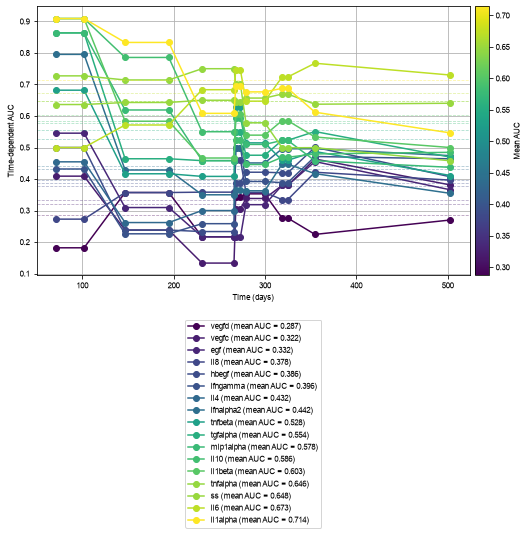

In [46]:
def get_cumulative_dynamic_auc(risk_score):
    auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_score, times)
    return auc, mean_auc

X_test_arr = np.asarray(X_test_transformed)

# 1) Compute all AUC curves first
feature_results = []
for i, col in enumerate(selected_features):
    auc, mean_auc = get_cumulative_dynamic_auc(X_test_arr[:, i])
    feature_results.append({"feature": col, "auc": auc, "mean_auc": mean_auc, "idx": i})

# 2) Sort by mean AUC (low -> high) for sequential coloring
feature_results = sorted(feature_results, key=lambda d: d["mean_auc"])

# 3) Build sequential palette mapped to mean AUC
mean_vals = np.array([d["mean_auc"] for d in feature_results])
norm = plt.Normalize(vmin=mean_vals.min(), vmax=mean_vals.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(np.array([20, 20]) * 0.393701))  # cm -> inches

handles, labels = [], []
for d in feature_results:
    color = cmap(norm(d["mean_auc"]))
    line, = ax.plot(
        times,
        d["auc"],
        marker="o",
        color=color,
        linewidth=1.5,
        label=f"{d['feature']} (mean AUC = {d['mean_auc']:.3f})",
    )
    ax.axhline(d["mean_auc"], color=color, linestyle="--", linewidth=0.8, alpha=0.4)
    handles.append(line)
    labels.append(f"{d['feature']} (mean AUC = {d['mean_auc']:.3f})")

    # optional: keep IPCW calculation
    _ = concordance_index_ipcw(y_train, y_test, X_test_arr[:, d["idx"]], tau=times[-1])

ax.set_xlabel("Time (days)", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.set_ylabel("Time-dependent AUC", fontsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.grid(True)

# Legend (ordered low -> high mean AUC)
ax.legend(handles, labels, loc="upper center", fontsize=8, bbox_to_anchor=(0.5, -0.15), ncol=1)

# Colorbar to show mean AUC -> color mapping
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Mean AUC", fontsize=8)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(
    "../figures/time-dependent-auc_individual-feature-llu_within2yrs.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

In [ ]:
# def plot_cumulative_dynamic_auc(risk_score, label, color=None, ax=None):
#     if ax is None:
#         ax = plt.gca()

#     auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_score, times)

#     ax.plot(times, auc, marker="o", markersize=4, linewidth=1.8, color=color, label=label)
#     ax.axhline(mean_auc, color=color, linestyle="--", linewidth=1, alpha=0.6)
#     return mean_auc

# numeric_features = ["tnfalpha", "il4", "il10", "ifnalpha2"]
# X_test_arr = np.asarray(X_test_transformed)

# fig, ax = plt.subplots(figsize=(16, 10))

# mean_aucs = []
# for i, col in enumerate(numeric_features):
#     mean_auc = plot_cumulative_dynamic_auc(X_test_arr[:, i], col, color=f"C{i}", ax=ax)
#     mean_aucs.append((col, mean_auc))
#     ret = concordance_index_ipcw(y_train, y_test, X_test_arr[:, i], tau=times[-1])

# ax.set_xlabel("Time (days)", fontsize=20)
# ax.tick_params(axis="x", labelsize=18)
# ax.set_ylabel("Time-dependent AUC", fontsize=20)
# ax.tick_params(axis="y", labelsize=18)
# ax.set_title("Time-dependent AUC by variable", fontsize=22, fontweight="bold")
# ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="Chance (AUC = 0.5)")

# # legend OUTSIDE the plot area, to the right — no overlap with lines regardless of curve shape
# ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=16, frameon=False, title="")

# plt.tight_layout()
# # fig.savefig("../figures/time_dependent_auc.png", dpi=300, bbox_inches="tight")
# plt.show()

In [ ]:
# def plot_cumulative_dynamic_auc(risk_score, label, color=None, ax=None):
#     if ax is None:
#         ax = plt.gca()

#     auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_score, times)

#     ax.plot(times, auc, marker="o", markersize=4, linewidth=1.8, color=color, label=label)
#     ax.axhline(mean_auc, color=color, linestyle="--", linewidth=1, alpha=0.6)
#     return mean_auc

# # numeric_features = ["il6", "il8", "il10", "tnfalpha", "ss"]

# X_test_arr = np.asarray(X_test_transformed)

# # --- compute mean_auc for all features first, then keep only the top 5 ---
# mean_auc_lookup = []
# for i, col in enumerate(numeric_features):
#     _, mean_auc = cumulative_dynamic_auc(y_train, y_test, X_test_arr[:, i], times)
#     mean_auc_lookup.append((col, i, mean_auc))

# top5 = sorted(mean_auc_lookup, key=lambda x: x[2], reverse=True)[:5]
# numeric_features = [col for col, i, mean_auc in top5]
# top5_indices = [i for col, i, mean_auc in top5]

# fig, ax = plt.subplots(figsize=(16, 10))

# mean_aucs = []
# for i, col in zip(top5_indices, numeric_features):
#     mean_auc = plot_cumulative_dynamic_auc(X_test_arr[:, i], col, color=f"C{i}", ax=ax)
#     mean_aucs.append((col, mean_auc))
#     ret = concordance_index_ipcw(y_train, y_test, X_test_arr[:, i], tau=times[-1])

# ax.set_xlabel("Time (days)", fontsize=20)
# ax.tick_params(axis="x", labelsize=18)
# ax.set_ylabel("Time-dependent AUC", fontsize=20)
# ax.tick_params(axis="y", labelsize=18)
# ax.set_title("Time-dependent AUC by variable", fontsize=22, fontweight="bold")
# ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="Chance (AUC = 0.5)")

# # legend OUTSIDE the plot area, to the right — no overlap with lines regardless of curve shape
# ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=16, frameon=False, title="")

# plt.tight_layout()
# # fig.savefig("../figures/time_dependent_auc_top5.png", dpi=300, bbox_inches="tight")
# plt.show()

In [65]:
X_train_transformed

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,ss
108,-0.621682,0.010195,2.194258,-0.428896,-0.304592,0.077633,0.213550,0.369412,-0.487253,0.386685,-0.200744,1.471352,0.250061,0.642862,1.393213,1.876202,2.238938
98,-0.698432,-0.473093,-0.828564,-0.428896,-0.455074,-0.871164,-0.401854,-0.725761,-0.251533,-0.811957,-0.287599,-0.671103,-0.750899,-0.679102,-0.935164,-0.302962,1.495410
86,-0.805445,-0.380549,-1.203673,-0.428896,-0.455074,-0.570555,1.066442,-0.305233,-0.106451,-0.811957,-0.268328,-0.392171,-0.542637,-0.097051,-0.008472,-0.549910,0.751882
73,-0.429204,-0.068454,-0.311464,0.274139,-0.374583,-0.321614,-0.472756,-0.320974,-0.546838,-0.209849,-0.253544,-0.163704,-0.307040,-0.444554,1.064200,-0.471324,2.238938
93,0.120631,0.153598,0.424846,1.259879,1.500319,0.021269,0.259671,0.834917,0.524863,0.800356,0.045301,0.003289,0.887864,-0.388249,0.808709,-0.657667,0.751882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,-0.805445,-0.513668,-0.870284,-0.428896,-0.455074,-0.810103,-0.664812,-0.665043,-0.468160,-0.811957,-0.200744,-0.997747,-0.542637,-1.095000,-0.809631,-0.155871,0.008354
95,-0.103322,-0.380549,1.246790,0.339224,0.637671,0.077633,-0.570505,-0.521119,0.211094,0.590176,-0.151905,-1.016098,-0.018077,0.007270,-0.119355,-0.476344,0.751882
42,-0.732811,-0.512557,-0.613380,-0.428896,-0.455074,-0.349796,-0.196031,-0.458152,-0.060922,-0.650280,-0.278887,-0.322438,-0.605116,-0.185481,2.064997,-0.286669,-0.735174
68,0.801933,0.124973,-0.178255,-0.272921,-0.073619,-0.180703,-0.573259,0.355919,0.004118,0.264033,-0.229256,-0.972973,6.417223,-0.664939,-0.665641,-0.720741,-1.478701


In [66]:
X_test_transformed.head()

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,ss
100,-0.698432,-0.513668,0.791171,-0.264319,-0.264346,-0.096157,0.175689,1.909852,-0.011617,0.417348,-0.219752,0.172116,0.160248,1.406265,2.118483,0.250839,1.495410
81,-0.805445,-0.425014,0.156964,-0.428896,-0.455074,-0.331008,0.129569,-0.201787,-0.521451,-0.811957,-0.249848,0.607030,-0.413775,-0.305000,-1.224620,-0.891284,0.751882
13,0.738742,-0.422791,-0.513108,-0.407106,-0.455074,-0.462524,-0.652421,-0.388439,-0.543062,-0.811957,-0.265952,-0.329778,-0.428093,-0.370632,-0.801706,-0.416973,-0.735174
5,0.798543,0.029371,0.246624,-0.368112,-0.334338,-0.039793,0.486145,-0.208534,-0.362627,-0.392154,-0.220544,-0.485760,-0.468444,0.038013,1.217454,-0.645858,0.751882
36,0.009502,2.992743,4.409775,3.418586,5.701569,2.557656,-0.249724,0.272713,-0.162155,2.213082,5.621442,3.377082,21.883289,1.462915,-0.597985,-0.407921,0.751882


C-index: 0.744
Mean AUC: 0.762


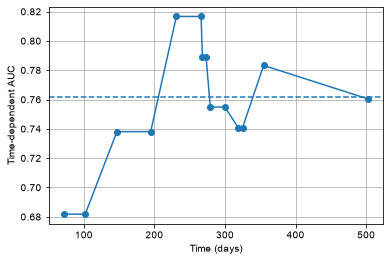

In [68]:
cph = CoxPHSurvivalAnalysis()
cph.fit(X_train_transformed, y_train)
c_index = cph.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

cph_risk_scores = cph.predict(X_test_transformed)
cph_auc, cph_mean_auc = cumulative_dynamic_auc(y_train, y_test, cph_risk_scores, times)
print(f"Mean AUC: {cph_mean_auc:.3f}")

plt.plot(times, cph_auc, marker="o")
plt.axhline(cph_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

C-index: 0.667
Mean AUC: 0.654


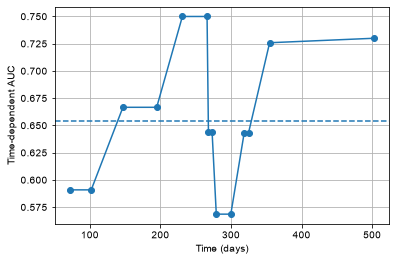

In [69]:
gbsa_tree = GradientBoostingSurvivalAnalysis(random_state=2026)
gbsa_tree.fit(X_train_transformed, y_train)
c_index = gbsa_tree.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

gbsa_tree_risk_scores = gbsa_tree.predict(X_test_transformed)
gbsa_tree_auc, gbsa_tree_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_tree_risk_scores, times)
print(f"Mean AUC: {gbsa_tree_mean_auc:.3f}")

plt.plot(times, gbsa_tree_auc, marker="o")
plt.axhline(gbsa_tree_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

C-index: 0.635
Mean AUC: 0.654


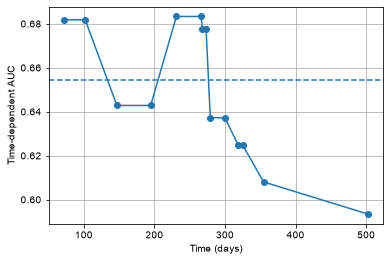

In [70]:
gbsa_ls = ComponentwiseGradientBoostingSurvivalAnalysis(random_state=2026)
gbsa_ls.fit(X_train_transformed, y_train)
cindex = gbsa_ls.score(X_test_transformed, y_test)
print(f"C-index: {round(cindex, 3)}")

gbsa_ls_risk_scores = gbsa_ls.predict(X_test_transformed)
gbsa_ls_auc, gbsa_ls_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_ls_risk_scores, times)
print(f"Mean AUC: {gbsa_ls_mean_auc:.3f}")

plt.plot(times, gbsa_ls_auc, marker="o")
plt.axhline(gbsa_ls_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

C-index: 0.744
Mean AUC: 0.733


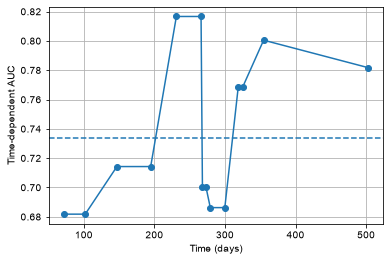

In [71]:
rsf = RandomSurvivalForest(random_state=2026)
rsf.fit(X_train_transformed, y_train)
c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

plt.plot(times, rsf_auc, marker="o")
plt.axhline(rsf_mean_auc, linestyle="--")
plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.grid(True)

In [72]:
# Permutation-based feature importance
result = permutation_importance(rsf, X_test_transformed, y_test, n_repeats=15, random_state=2026)

pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test_transformed.columns,
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
ss,0.097436,0.102034
vegfd,0.047863,0.029316
vegfc,0.006410,0.016217
il1alpha,0.005128,0.009421
il6,0.003846,0.012778
tgfalpha,-0.000427,0.010589
tnfbeta,-0.000855,0.008063
il8,-0.001709,0.008903
tnfalpha,-0.002137,0.017147
egf,-0.002991,0.009613


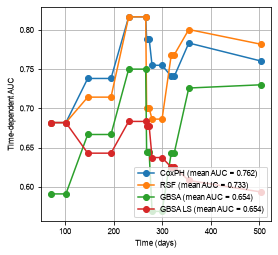

In [74]:
# Plot all models together for comparison
fig, ax = plt.subplots(figsize=(10.5, 10, "cm"), facecolor="white")
ax.set_facecolor("white")

ax.plot(times, cph_auc, "o-", label=f"CoxPH (mean AUC = {cph_mean_auc:.3f})")
ax.plot(times, rsf_auc, "o-", label=f"RSF (mean AUC = {rsf_mean_auc:.3f})")
ax.plot(times, gbsa_tree_auc, "o-", label=f"GBSA (mean AUC = {gbsa_tree_mean_auc:.3f})")
ax.plot(times, gbsa_ls_auc, "o-", label=f"GBSA LS (mean AUC = {gbsa_ls_mean_auc:.3f})")
ax.set_xlabel("Time (days)", fontsize = 8)
ax.tick_params(axis="x", labelsize=8)
ax.set_ylabel("Time-dependent AUC", fontsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_title("", fontsize=8, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)

# fig.savefig("../figures/time_dependent_auc_full_model_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")